# MAMMAL Model Inference

Run inference with a finetuned MAMMAL model on **any CSV file** containing SMILES strings.

All dataset, dataloader and task logic lives in **`mammal_utils.py`** (same folder).

## Steps
0. Configuration — edit paths here
1. Preview input data
2. Load tokenizer
3. Load model
4. Build DataLoader
5. Run inference
6. Inspect predictions
7. Evaluate (if labels available)
8. Enrichment metrics (Precision@K / EF@K)
9. Top hits

In [ ]:
!pip install biomed-multi-alignment

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 4.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.0/75.0 kB 9.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.9/97.9 kB 10.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 274.2/274.2 kB 20.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 482.8/482.8 kB 35.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 113.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 84.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 18.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 53.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 65.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.4/91.4 kB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

## 0. Configuration

**Edit the paths below before running.**

In [ ]:
import os
import torch

RUN_ON_WDR91 = False
if RUN_ON_WDR91:
    MODEL_PATH = "michalozeryflato/biomed.omics.bl.sm.ma-ted-458m.wdr91_asms"
    DATA_PATH = "/content/wdr91_test.csv"
    SMILES_COLUMN = "SMILES"
    OUTPUT_PATH = "/content/results/mammal_wdr91_test_predictions.csv"
    LABEL_COLUMN  = "Label"
else:
    MODEL_PATH = "michalozeryflato/biomed.omics.bl.sm.ma-ted-458m.pgk2_del_cdd"
    #DATA_PATH = "/content/creative_test.csv"
    DATA_PATH = "/content/test.csv"
    SMILES_COLUMN = "smiles"
    OUTPUT_PATH = "/content/results/mammal_pgk2_del_creative_predictions.csv"
    LABEL_COLUMN  = "label"



# Base MAMMAL tokenizer / model (HuggingFace hub id or local path)
BASE_MODEL_PATH = "ibm/biomed.omics.bl.sm.ma-ted-458m"

# Inference device
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# ── VALIDATION ─────────────────────────────────────────────────────────────────
# assert os.path.exists(MODEL_PATH), f"Model not found: {MODEL_PATH}"
assert os.path.exists(DATA_PATH),  f"Data not found:  {DATA_PATH}"
os.makedirs(os.path.dirname(OUTPUT_PATH) or ".", exist_ok=True)

print(f"Model : {MODEL_PATH}")
print(f"Data  : {DATA_PATH}")
print(f"Output: {OUTPUT_PATH}")
print(f"Device: {DEVICE}")

Model : michalozeryflato/biomed.omics.bl.sm.ma-ted-458m.pgk2_del_cdd
Data  : /content/test.csv
Output: /content/results/mammal_pgk2_del_creative_predictions.csv
Device: cuda


## 1. Preview Input Data

In [ ]:
import pandas as pd
input_df = pd.read_csv(DATA_PATH)
input_df["sample_id"] = input_df.index


print(f"\nLabel distribution:")
print(input_df[LABEL_COLUMN].value_counts().sort_index())

display(input_df)


Label distribution:
label
0    13280
1     1468
Name: count, dtype: int64


,smiles,label,sample_id
0,CNC(=O)[C@@H]1CN(Cc2ccc(OCc3cccc(C(=O)NCc4cc(C...,0,0
1,CNC(=O)[C@@H]1[C@H]2CC[C@H](C2)[C@@H]1n1c(C(C)...,0,1
2,CNC(=O)CC1CCN(C(=O)C(Cc2ccc(C#CCOc3c(C(F)(F)F)...,0,2
3,CNC(=O)[C@@H]1C[C@H]2CCN(Cc3ccc(OCc4ccc(C(=O)N...,0,3
4,CNC(=O)C1CCN(C(=O)[C@H]2CN(C(=O)c3cnc4[nH]cnc4...,1,4
...,...,...,...
14743,CNC(=O)C[C@@H](Cc1ccccc1)n1c(-c2ccc3c(c2)oc(=O...,0,14743
14744,CNC(=O)C[C@H](c1ccccc1)n1c(C2CCCCC2C)nc2cc(CNC...,0,14744
14745,CO[C@@]1(C)CCN(C(=O)[C@H]2CC[C@H](CN(CC(=O)O)C...,0,14745
14746,Cc1ccc(N)cc1CN(C)C(=O)C1(c2cccc(C(=O)NCCCn3ccn...,1,14746


In [ ]:
#Clustering #Leili - remove my name in final notebook
!pip install rdkit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.7/36.7 MB 33.0 MB/s eta 0:00:00


In [ ]:
#Clustering #Leili - remove my name in final notebook
from rdkit import Chem
from rdkit import DataStructs
from rdkit.Chem import AllChem, MACCSkeys
from rdkit.ML.Cluster import Butina

def cluster_molecules(smiles_list, cutoff=0.35, fp_type='morgan2'):
    """
    Clusters SMILES strings with selectable fingerprint types.

    Args:
        smiles_list (list): List of SMILES strings.
        cutoff (float): Distance threshold (1 - similarity).
        fp_type (str): 'morgan' (ECFP4), 'maccs' (Keys), or 'rdkit' (Path-based).
    """
    mols = [Chem.MolFromSmiles(s) for s in smiles_list]
    valid_mols = [m for m in mols if m is not None]

    if len(valid_mols) < len(smiles_list):
        print(f"Warning: {len(smiles_list) - len(valid_mols)} invalid SMILES skipped.")

    # Generate the requested fingerprint type
    fps = []
    for m in valid_mols:
        if fp_type.lower() == 'morgan2' or fp_type.lower() == 'ecfp4':
            fps.append(AllChem.GetMorganFingerprintAsBitVect(m, 2, nBits=2048))
        elif fp_type.lower() == 'morgan3' or fp_type.lower() == 'ecfp6':
            fps.append(AllChem.GetMorganFingerprintAsBitVect(m, 3, nBits=2048))
        elif fp_type.lower() == 'maccs':
            fps.append(MACCSkeys.GenMACCSKeys(m))
        elif fp_type.lower() == 'rdkit':
            fps.append(Chem.RDKFingerprint(m))
        else:
            raise ValueError("fp_type must be 'morgan2', 'ecfp4', 'morgan3', 'ecfp6', 'maccs', or 'rdkit'")

    # Generate distance matrix
    num_fps = len(fps)
    dist_matrix = []
    for i in range(1, num_fps):
        sims = DataStructs.BulkTanimotoSimilarity(fps[i], fps[:i])
        dist_matrix.extend([1 - x for x in sims])

    # Cluster using Butina
    clusters = Butina.ClusterData(dist_matrix, num_fps, cutoff, isDistData=True)
    return clusters

def interpret_clusters(clusters):
    clusters_df = pd.DataFrame()
    ele_list=[]
    clusid_list=[]
    clussize_list=[]
    centroid_list=[]
    for clusid,t in enumerate(clusters):
        clussize=len(t)
        for c,ele in enumerate(t):
            ele_list.append(ele)
            clusid_list.append(clusid)
            clussize_list.append(clussize)
            if c == 0:
                centroid_list.append(1)
            else:
                centroid_list.append(0)
    clusters_df["ID"]=ele_list
    clusters_df["CLUSTER_ID"]=clusid_list
    clusters_df["CLUSTER_SIZE"]=clussize_list
    clusters_df["CLUSTER_CENTROID"]=centroid_list
    return clusters_df.sort_values(by="ID").reset_index(drop=True)

In [ ]:
#Clustering #Leili - remove my name in final notebook
clusters=cluster_molecules(input_df[SMILES_COLUMN],cutoff=0.35,fp_type="morgan2")

Streaming output truncated to the last 5000 lines.
[21:45:51] DEPRECATION WARNING: please use MorganGenerator
[21:45:51] DEPRECATION WARNING: please use MorganGenerator
[21:45:51] DEPRECATION WARNING: please use MorganGenerator
[21:45:51] DEPRECATION WARNING: please use MorganGenerator
[21:45:51] DEPRECATION WARNING: please use MorganGenerator
[21:45:51] DEPRECATION WARNING: please use MorganGenerator
[21:45:51] DEPRECATION WARNING: please use MorganGenerator
[21:45:51] DEPRECATION WARNING: please use MorganGenerator
[21:45:51] DEPRECATION WARNING: please use MorganGenerator
[21:45:51] DEPRECATION WARNING: please use MorganGenerator
[21:45:51] DEPRECATION WARNING: please use MorganGenerator
[21:45:51] DEPRECATION WARNING: please use MorganGenerator
[21:45:51] DEPRECATION WARNING: please use MorganGenerator
[21:45:51] DEPRECATION WARNING: please use MorganGenerator
[21:45:51] DEPRECATION WARNING: please use MorganGenerator
[21:45:51] DEPRECATION WARNING: please use MorganGenerator
[21:4

NameError: name 'interpret_clusters' is not defined

In [ ]:
#Clustering #Leili - remove my name in final notebook
clusters_df=interpret_clusters(clusters)
input_df_wclus=pd.concat([input_df,clusters_df],axis=1)
display(input_df_wclus)

,smiles,label,sample_id,ID,CLUSTER_ID,CLUSTER_SIZE,CLUSTER_CENTROID
0,CNC(=O)[C@@H]1CN(Cc2ccc(OCc3cccc(C(=O)NCc4cc(C...,0,0,0,12950,1,1
1,CNC(=O)[C@@H]1[C@H]2CC[C@H](C2)[C@@H]1n1c(C(C)...,0,1,1,12949,1,1
2,CNC(=O)CC1CCN(C(=O)C(Cc2ccc(C#CCOc3c(C(F)(F)F)...,0,2,2,12948,1,1
3,CNC(=O)[C@@H]1C[C@H]2CCN(Cc3ccc(OCc4ccc(C(=O)N...,0,3,3,12947,1,1
4,CNC(=O)C1CCN(C(=O)[C@H]2CN(C(=O)c3cnc4[nH]cnc4...,1,4,4,0,275,0
...,...,...,...,...,...,...,...
14743,CNC(=O)C[C@@H](Cc1ccccc1)n1c(-c2ccc3c(c2)oc(=O...,0,14743,14743,634,1,1
14744,CNC(=O)C[C@H](c1ccccc1)n1c(C2CCCCC2C)nc2cc(CNC...,0,14744,14744,633,1,1
14745,CO[C@@]1(C)CCN(C(=O)[C@H]2CC[C@H](CN(CC(=O)O)C...,0,14745,14745,632,1,1
14746,Cc1ccc(N)cc1CN(C)C(=O)C1(c2cccc(C(=O)NCCCn3ccn...,1,14746,14746,631,1,1


In [ ]:
#Draw clusters #Leili - remove my name in final notebook
from rdkit.Chem.Draw import IPythonConsole
from rdkit.Chem import Draw
import numpy as np
IPythonConsole.drawOptions.minFontSize = 20
def plotmolblocks_n(smilist,n=20,molsPerRow=5,labels=None):
    mols = [Chem.MolFromSmiles(s) for s in smilist]
    valid_mols = [m for m in mols if m is not None]
    mollen=len(valid_mols)
    n_figs=mollen // n + 1
    imglist=[]
    for i in range(1):
        molblock=valid_mols[i*n:min((i+1)*n,mollen)]
        legends=[]
        if labels is not None:
            assert isinstance(labels, pd.DataFrame)
            keys=labels.keys()
            for index,label in labels.iloc[i*n:min((i+1)*n,mollen)].iterrows():
                legend=""
                for key in keys:
                    if isinstance(label[key], int):
                        legend=legend+f"{key}: {label[key]:d}\n"
                    elif isinstance(label[key], float) or isinstance(label[key], np.float64):
                        if label[key].is_integer():
                            legend=legend+f"{key}: {label[key]:.0f}\n"
                        else:
                            legend=legend+f"{key}: {label[key]:.6f}\n"
                    else:
                        legend=legend+f"{key}: {label[key]}\n"
                legends.append(legend)
        img=Draw.MolsToGridImage(molblock,molsPerRow=molsPerRow,subImgSize=(400,400),returnPNG=False,legends=legends)
        imglist.append(img)
    return imglist

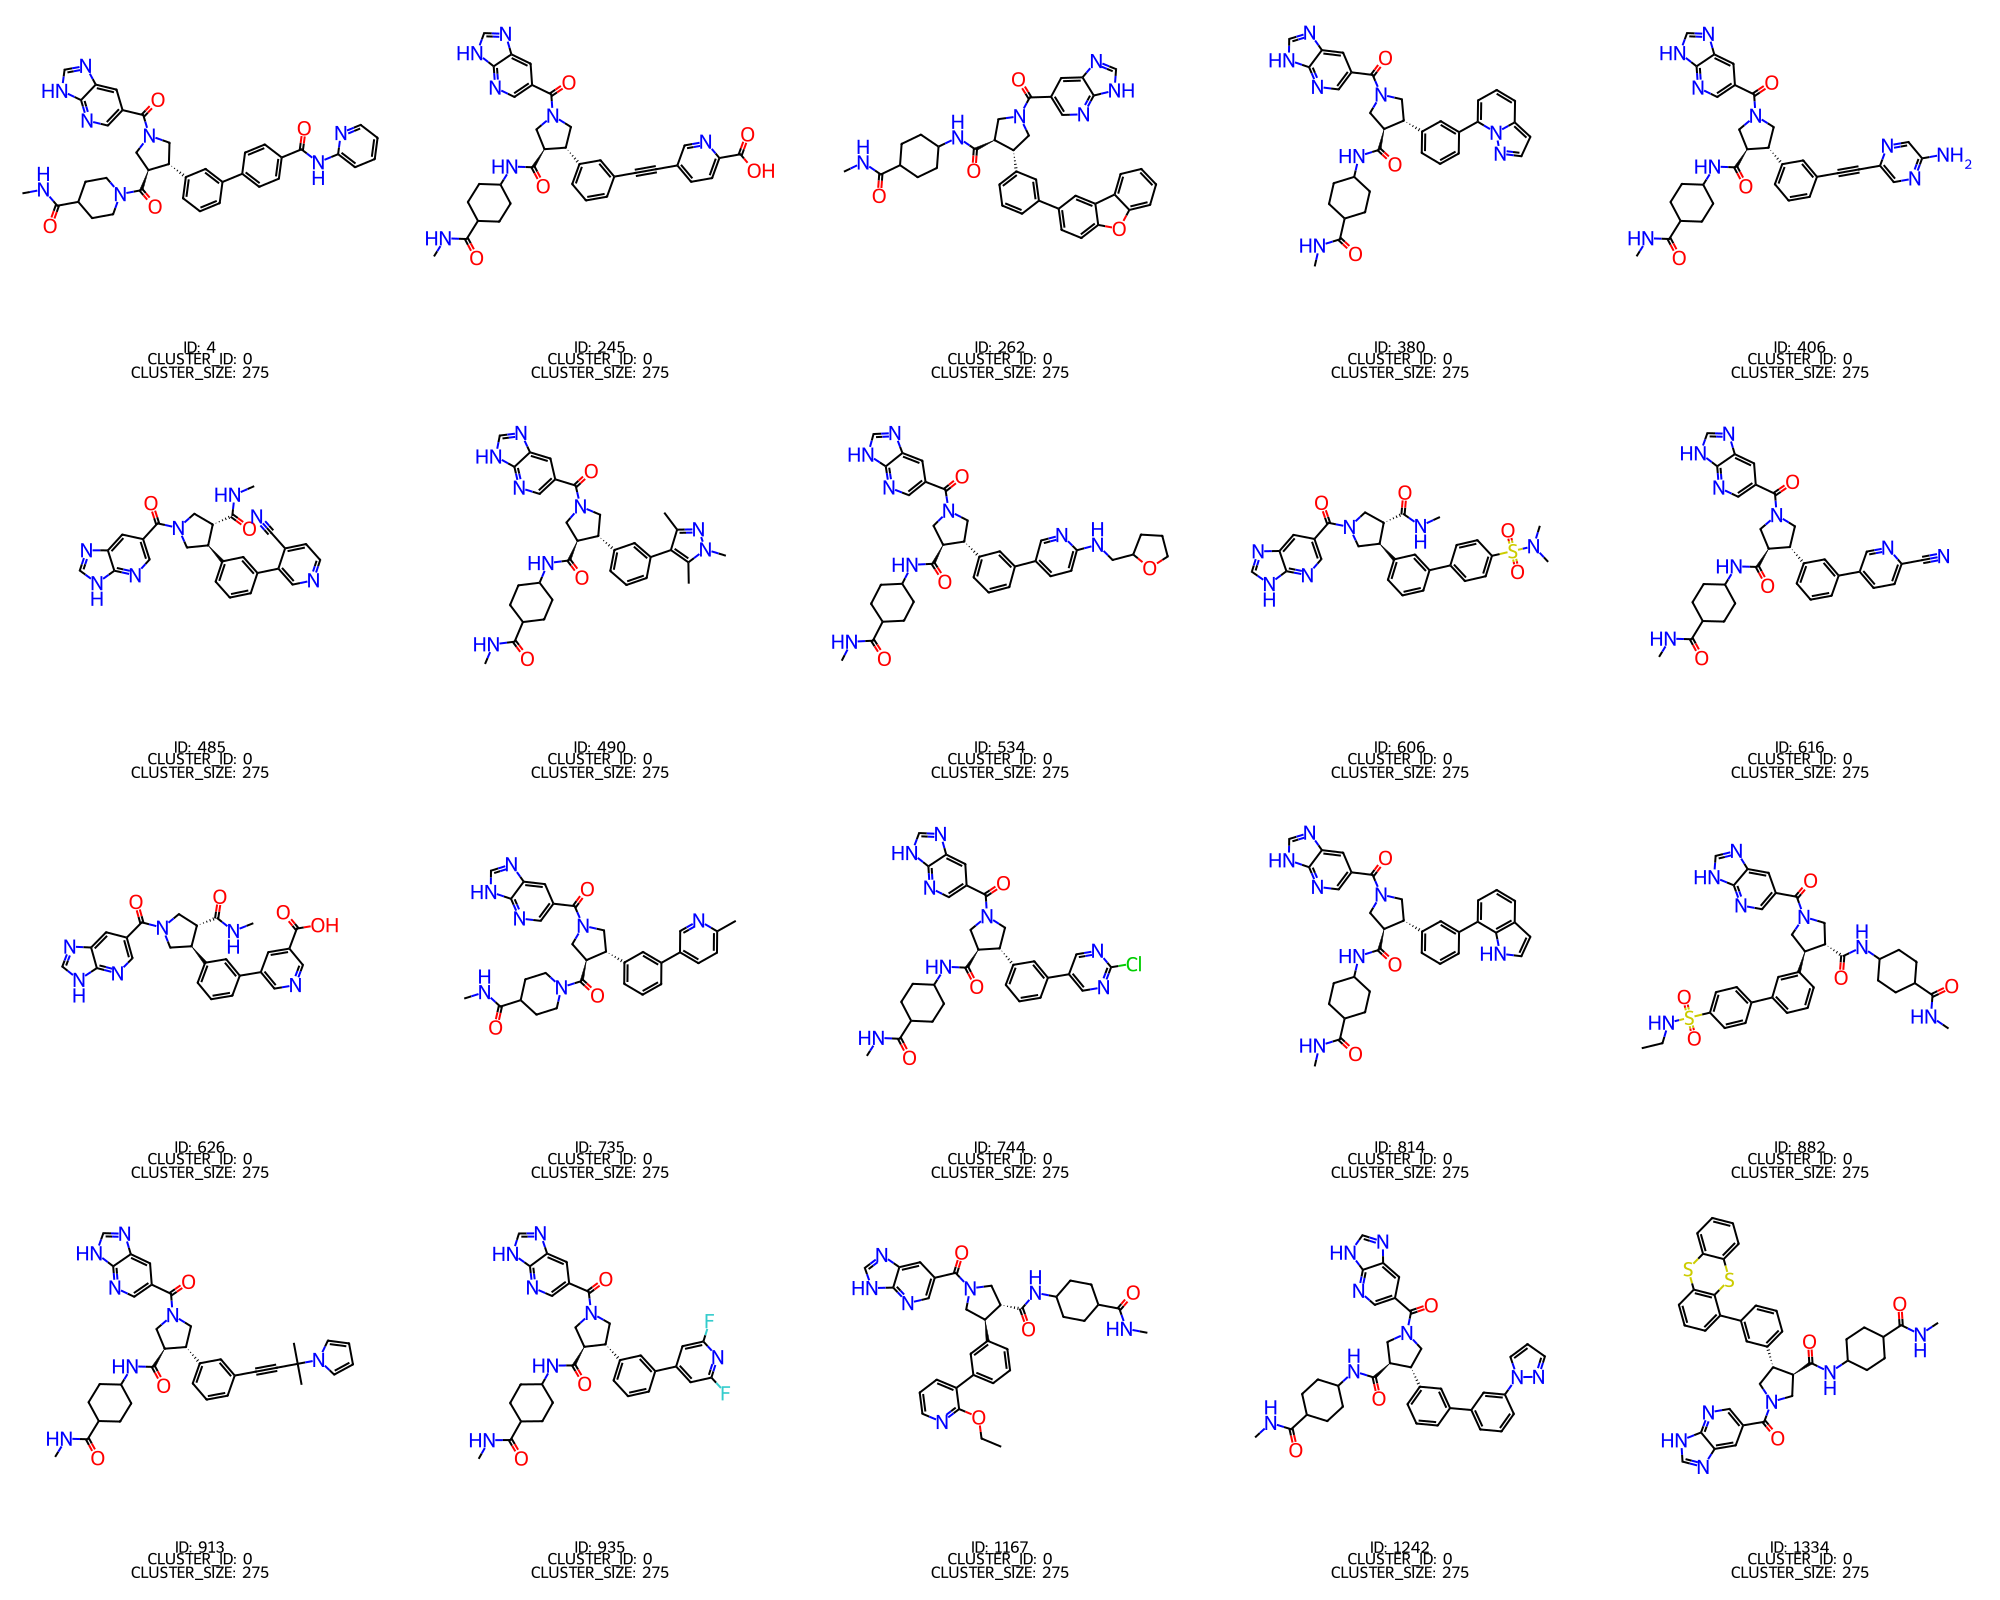

In [ ]:
#Draw clusters #Leili - remove my name in final notebook
df_to_draw=input_df_wclus[input_df_wclus["CLUSTER_ID"]==0]
imglist=plotmolblocks_n(df_to_draw[SMILES_COLUMN],labels=df_to_draw[["ID","CLUSTER_ID","CLUSTER_SIZE"]])
imglist[0]

## 2. Load Tokenizer

In [ ]:
from fuse.data.tokenizers.modular_tokenizer.op import ModularTokenizerOp
tokenizer_op = ModularTokenizerOp.from_pretrained(BASE_MODEL_PATH)
print("Tokenizer loaded.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

config.yaml:   0%|          | 0.00/967 [00:00<?, ?B/s]

t5_tokenizer_AA_special.json: 0.00B [00:00, ?B/s]

gene_tokenizer.json: 0.00B [00:00, ?B/s]

(…)th_aug_4272372_samples_balanced_1_1.json: 0.00B [00:00, ?B/s]

cell_attributes_tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizer loaded.


## 3. Load Model

In [ ]:
from mammal.model import Mammal
from huggingface_hub import hf_hub_download
from fuse.dl.lightning.pl_module import LightningModuleDefault

base_model = Mammal.from_pretrained(BASE_MODEL_PATH)

checkpoint_path = hf_hub_download(
            repo_id=MODEL_PATH,
            filename="last.ckpt",
            revision="main",
        )
pl_module = LightningModuleDefault.load_from_checkpoint(
        checkpoint_path=checkpoint_path,
        model=base_model,
        model_dir=None,
        map_location="cpu",
    )
model = pl_module._model  # extract the inner Mammal
model.eval().to(DEVICE)

Path doesn't exist. Will try to download from hf hub. pretrained_model_name_or_path='ibm/biomed.omics.bl.sm.ma-ted-458m'


Fetching 10 files:   0%|          | 0/10 [00:00<?, ?it/s]

README.md: 0.00B [00:00, ?B/s]

.gitattributes: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

mammal.png:   0%|          | 0.00/353k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.83G [00:00<?, ?B/s]

Attempting to load model from dir: pretrained_model_name_or_path='/root/.cache/huggingface/hub/models--ibm--biomed.omics.bl.sm.ma-ted-458m/snapshots/6d319d8dcf97f8821635327fc8cda24670553daa'


last.ckpt:   0%|          | 0.00/4.65G [00:00<?, ?B/s]

Mammal(
  (t5_model): T5ForConditionalGeneration(
    (shared): Embedding(100001, 768)
    (encoder): T5Stack(
      (embed_tokens): Embedding(100001, 768)
      (block): ModuleList(
        (0): T5Block(
          (layer): ModuleList(
            (0): T5LayerSelfAttention(
              (SelfAttention): T5Attention(
                (q): Linear(in_features=768, out_features=768, bias=False)
                (k): Linear(in_features=768, out_features=768, bias=False)
                (v): Linear(in_features=768, out_features=768, bias=False)
                (o): Linear(in_features=768, out_features=768, bias=False)
                (relative_attention_bias): Embedding(32, 12)
              )
              (layer_norm): T5LayerNorm()
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (1): T5LayerFF(
              (DenseReluDense): T5DenseGatedActDense(
                (wi_0): Linear(in_features=768, out_features=2048, bias=False)
                (wi_1): Linear(i

## 4. Build DataLoader

In [ ]:
from torch.utils.data import DataLoader, Dataset
from fuse.data.utils.collates import CollateDefault
from mammal.keys import *
from functools import partial

In [ ]:
class InferenceDataset(Dataset):
    def __init__(
        self,
        df: pd.DataFrame,
        smiles_column: str,
        tokenizer_op: ModularTokenizerOp,
        drug_max_seq_length: int = 300,
        encoder_input_max_seq_len: int = 320,

    ) -> None:
        self.smiles = df[smiles_column].tolist()
        self.indices = df.index.tolist()
        self.tokenizer_op = tokenizer_op
        self.drug_max_seq_length = drug_max_seq_length
        self.encoder_input_max_seq_len=encoder_input_max_seq_len
        print(f"InferenceDataset: {len(self.smiles)} samples")

    def __len__(self) -> int:
        return len(self.smiles)

    def __getitem__(self, idx: int) -> dict:
        drug_sequence = self.smiles[idx]

        sample: dict = {
            "index": self.indices[idx],
            "data.smiles": drug_sequence,
        }

        # ── Encoder input ──────────────────────────────────────────────────────
        sample[ENCODER_INPUTS_STR] = (
            f"<@TOKENIZER-TYPE=SMILES><SENTINEL_ID_0>"
            f"<MOLECULAR_ENTITY><MOLECULAR_ENTITY_SMALL_MOLECULE>"
            f"<@TOKENIZER-TYPE=SMILES@MAX-LEN={self.drug_max_seq_length}>"
            f"<SEQUENCE_NATURAL_START>{drug_sequence}<SEQUENCE_NATURAL_END><EOS>"
        )
        self.tokenizer_op(
            sample_dict=sample,
            key_in=ENCODER_INPUTS_STR,
            key_out_tokens_ids=ENCODER_INPUTS_TOKENS,
            key_out_attention_mask=ENCODER_INPUTS_ATTENTION_MASK,
            max_seq_len=self.encoder_input_max_seq_len,
        )
        sample[ENCODER_INPUTS_TOKENS] = torch.tensor(sample[ENCODER_INPUTS_TOKENS])
        sample[ENCODER_INPUTS_ATTENTION_MASK] = torch.tensor(
            sample[ENCODER_INPUTS_ATTENTION_MASK]
        )
        return sample

In [ ]:
def build_dataloader(
    df: pd.DataFrame,
    tokenizer_op: ModularTokenizerOp,
    smiles_column: str = "smiles",
    batch_size: int = 128,
    drug_max_seq_length: int = 300,
    encoder_input_max_seq_len:int=320,
    num_workers: int = 0,
) -> DataLoader:

    dataset = InferenceDataset(
        df=df,
        smiles_column=smiles_column,
        tokenizer_op=tokenizer_op,
        drug_max_seq_length=drug_max_seq_length,
        encoder_input_max_seq_len=encoder_input_max_seq_len,
    )

    pad_token_id = tokenizer_op.get_token_id("<PAD>")
    special_handlers = {
        ENCODER_INPUTS_TOKENS: partial(
            CollateDefault.crop_padding, pad_token_id=pad_token_id
        ),
        ENCODER_INPUTS_ATTENTION_MASK: partial(
            CollateDefault.crop_padding, pad_token_id=False
        ),
    }

    loader = DataLoader(
        dataset=dataset,
        batch_size=batch_size,
        collate_fn=CollateDefault(special_handlers_keys=special_handlers),
        shuffle=False,
        num_workers=num_workers,
    )
    return loader

In [ ]:
dataloader = build_dataloader(
    df=input_df,
    tokenizer_op=tokenizer_op,
    smiles_column=SMILES_COLUMN,
)

InferenceDataset: 14748 samples


In [ ]:
first_batch = next(iter(dataloader))

## 5. Run Inference

In [ ]:
from tqdm import tqdm
def run_inference(
    model: Mammal,
    dataloader: DataLoader,
    tokenizer_op: ModularTokenizerOp,
    device: str = "cpu",
    classification_position: int = 1,
) -> pd.DataFrame:

    negative_token_id = tokenizer_op.get_token_id("<0>")
    positive_token_id = tokenizer_op.get_token_id("<1>")
    label_map: dict[Any, int] = {negative_token_id: 0, positive_token_id: 1}

    results: dict[str, list] = {
        "sample_id": [],
        "predicted_label": [],
        "prediction_score": [],
    }

    model.eval()
    model = model.to(device)

    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Inference"):
            batch_size = batch[ENCODER_INPUTS_TOKENS].shape[0]

            # Build per-sample dicts for model.generate()
            sample_dicts = [
                {
                    ENCODER_INPUTS_TOKENS: batch[ENCODER_INPUTS_TOKENS][i].to(device),
                    ENCODER_INPUTS_ATTENTION_MASK: batch[ENCODER_INPUTS_ATTENTION_MASK][i].to(device),
                }
                for i in range(batch_size)
            ]

            batch_out = model.generate(
                sample_dicts,
                output_scores=True,
                return_dict_in_generate=True,
                max_new_tokens=5,
            )

            decoder_output = batch_out.get(CLS_PRED, None)  # (B, seq_len)
            decoder_scores = batch_out.get(SCORES, None)  # (B, seq_len, vocab)

            for i in range(batch_size):
                sample_id = batch["index"][i]

                if isinstance(sample_id, torch.Tensor):
                    sample_id = sample_id.item()

                predicted_label: int | None = None
                prediction_score: float | None = None

                if decoder_output is not None and decoder_scores is not None:
                    out_tokens = decoder_output[i].cpu().numpy()
                    out_scores = decoder_scores[i].cpu().numpy()  # (seq_len, vocab)

                    predicted_token = int(out_tokens[classification_position])
                    predicted_label = label_map.get(predicted_token, None)

                    prediction_score = float(
                        out_scores[classification_position, positive_token_id]
                    )

                results["sample_id"].append(sample_id)
                results["predicted_label"].append(predicted_label)
                results["prediction_score"].append(prediction_score)

    return pd.DataFrame(results)


In [ ]:
predictions_df = run_inference(
    model=model,
    dataloader=dataloader,
    tokenizer_op=tokenizer_op,
    device=DEVICE,
)

Inference: 100%|██████████| 116/116 [00:53<00:00,  2.15it/s]


In [ ]:
predictions_df.to_csv(OUTPUT_PATH, index=False)
print(f"\nSaved {len(predictions_df)} predictions to: {OUTPUT_PATH}")


Saved 14748 predictions to: /content/results/mammal_pgk2_del_creative_predictions.csv


In [ ]:
predictions_df = input_df.merge(predictions_df, on="sample_id")
predictions_df = predictions_df.rename(columns={LABEL_COLUMN:"true_label"})

## 6. Inspect Predictions

In [ ]:
print(f"Shape: {predictions_df.shape}")
print(f"\nPredicted label distribution:")
print(predictions_df["predicted_label"].value_counts().sort_index())
print(f"\nScore statistics:")
print(predictions_df["prediction_score"].describe())
display(predictions_df)

Shape: (14748, 5)

Predicted label distribution:
predicted_label
0    13462
1     1286
Name: count, dtype: int64

Score statistics:
count    1.474800e+04
mean     8.735212e-02
std      2.806227e-01
min      9.135981e-08
25%      3.696064e-07
50%      5.529360e-07
75%      1.327394e-06
max      9.999967e-01
Name: prediction_score, dtype: float64


,smiles,true_label,sample_id,predicted_label,prediction_score
0,CNC(=O)[C@@H]1CN(Cc2ccc(OCc3cccc(C(=O)NCc4cc(Cl)ccc4C)c3)c(OC)c2)C[C@H]1c1cnn(C)c1,0,0,0,1.143954e-06
1,CNC(=O)[C@@H]1[C@H]2CC[C@H](C2)[C@@H]1n1c(C(C)(C)CNC(=O)OC(C)(C)C)nc2cccc(CN3CCC(C#N)(c4ccccc4)CC3)c21,0,1,0,2.283699e-06
2,CNC(=O)CC1CCN(C(=O)C(Cc2ccc(C#CCOc3c(C(F)(F)F)nn(-c4ccccc4)c3C)cc2)NC(=O)C2CCN(S(=O)(=O)c3cccs3)CC2)CC1,0,2,0,9.135701e-07
3,CNC(=O)[C@@H]1C[C@H]2CCN(Cc3ccc(OCc4ccc(C(=O)NCCN5CCCS5(=O)=O)o4)c(OC)c3)C[C@H]21,0,3,0,2.026413e-06
4,CNC(=O)C1CCN(C(=O)[C@H]2CN(C(=O)c3cnc4[nH]cnc4c3)C[C@@H]2c2cccc(-c3ccc(C(=O)Nc4ccccn4)cc3)c2)CC1,1,4,1,9.999827e-01
...,...,...,...,...,...
14743,CNC(=O)C[C@@H](Cc1ccccc1)n1c(-c2ccc3c(c2)oc(=O)n3C)nc2ccc(O)c(CN[C@@H]3CCN(C)C3=O)c21,0,14743,0,2.563985e-07
14744,CNC(=O)C[C@H](c1ccccc1)n1c(C2CCCCC2C)nc2cc(CNCC3(O)CC(C)(C)N(C)C(C)(C)C3)ccc21,0,14744,0,1.781449e-07
14745,CO[C@@]1(C)CCN(C(=O)[C@H]2CC[C@H](CN(CC(=O)O)C[C@@H]3CCCN(S(=O)(=O)c4ccc(OC(F)F)cc4)C3)CC2)C1,0,14745,0,6.753664e-07
14746,Cc1ccc(N)cc1CN(C)C(=O)C1(c2cccc(C(=O)NCCCn3ccnc3)c2)CCC1,1,14746,0,8.178248e-07


## 7. Evaluate (if labels available)

CLASSIFICATION METRICS
Accuracy  : 0.9759
Precision : 0.9323
Recall    : 0.8168
F1 Score  : 0.8707
ROC AUC   : 0.9550
PR AUC    : 0.8683


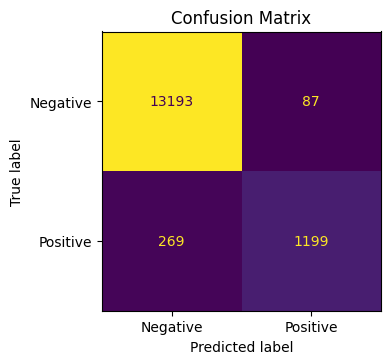

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    confusion_matrix, ConfusionMatrixDisplay,
)

valid   = predictions_df[predictions_df["true_label"].notna()].copy()
y_true  = valid["true_label"].astype(int)
y_pred  = valid["predicted_label"].astype(int)
y_score = valid["prediction_score"].astype(float)

print("=" * 50)
print("CLASSIFICATION METRICS")
print("=" * 50)
print(f"Accuracy  : {accuracy_score(y_true, y_pred):.4f}")
print(f"Precision : {precision_score(y_true, y_pred, zero_division=0):.4f}")
print(f"Recall    : {recall_score(y_true, y_pred, zero_division=0):.4f}")
print(f"F1 Score  : {f1_score(y_true, y_pred, zero_division=0):.4f}")
print(f"ROC AUC   : {roc_auc_score(y_true, y_score):.4f}")
print(f"PR AUC    : {average_precision_score(y_true, y_score):.4f}")

cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(4, 4))
ConfusionMatrixDisplay(cm, display_labels=["Negative", "Positive"]).plot(ax=ax, colorbar=False)
ax.set_title("Confusion Matrix")
plt.tight_layout()
plt.show()


## 8. Enrichment Metrics

Precision@K and Enrichment Factor (EF@K).

**EF@K** = Precision@K / hit_prevalence  
where hit_prevalence = fraction of positives in the full dataset.

In [ ]:
def calculate_enrichment_metrics(
    y_true,
    y_scores,
    top_k_values: list[int] | None = None,
) -> dict:
    if top_k_values is None:
        top_k_values = [10, 50, 100, 500, 1000, 2000]

    y_true = np.asarray(y_true)
    y_scores = np.asarray(y_scores)

    sorted_indices = np.argsort(y_scores)[::-1]
    sorted_labels = y_true[sorted_indices]

    hit_prevalence = np.sum(y_true) / len(y_true)

    enrichment: dict = {}
    for k in top_k_values:
        if k <= len(sorted_labels):
            top_k_labels = sorted_labels[:k]
            precision_at_k = np.sum(top_k_labels) / k
            enrichment[f"Precision@{k}"] = precision_at_k
            enrichment[f"EF@{k}"] = (
                precision_at_k / hit_prevalence if hit_prevalence > 0 else np.nan
            )
        else:
            enrichment[f"Precision@{k}"] = np.nan
            enrichment[f"EF@{k}"] = np.nan

    return enrichment

In [ ]:
import numpy as np

n_total = len(valid)
top_k_values = sorted({k for k in [10, 50, 100, 500, 1000, 2000] if k <= n_total})
if n_total not in top_k_values:
    top_k_values.append(n_total)

enrichment = calculate_enrichment_metrics(
    y_true.values, y_score.values, top_k_values=top_k_values
)

n_positives = int(y_true.sum())
hit_prev    = n_positives / n_total

print("=" * 60)
print("ENRICHMENT METRICS")
print("=" * 60)
print(f"Dataset : {n_total} compounds  |  Positives: {n_positives}  |  Hit rate: {hit_prev:.2%}")
print()
print(f"{'K':>8}  {'Precision@K':>12}  {'EF@K':>8}  {'Hits in top-K':>14}")
print("-" * 50)
for k in top_k_values:
    prec = enrichment.get(f"Precision@{k}", np.nan)
    ef   = enrichment.get(f"EF@{k}",        np.nan)
    hits = int(round(prec * k)) if not np.isnan(prec) else "N/A"
    print(f"{k:>8}  {prec:>12.4f}  {ef:>8.2f}  {hits:>14}")
print("=" * 60)

ef_rows = [
    {
        "K":             k,
        "Precision@K":   enrichment.get(f"Precision@{k}", np.nan),
        "EF@K":          enrichment.get(f"EF@{k}",        np.nan),
        "Hits_in_top_K": int(round(enrichment.get(f"Precision@{k}", 0) * k)),
    }
    for k in top_k_values
]
ef_df = pd.DataFrame(ef_rows)
ef_df


ENRICHMENT METRICS
Dataset : 14748 compounds  |  Positives: 1468  |  Hit rate: 9.95%

       K   Precision@K      EF@K   Hits in top-K
--------------------------------------------------
      10        0.9000      9.04               9
      50        0.8800      8.84              44
     100        0.9400      9.44              94
     500        0.9780      9.83             489
    1000        0.9870      9.92             987
    2000        0.6235      6.26            1247
   14748        0.0995      1.00            1468


,K,Precision@K,EF@K,Hits_in_top_K
0,10,0.900000,9.041689,9
1,50,0.880000,8.840763,44
2,100,0.940000,9.443542,94
3,500,0.978000,9.825302,489
4,1000,0.987000,9.915719,987
5,2000,0.623500,6.263881,1247
6,14748,0.099539,1.000000,1468


## 9. Top Hits

In [ ]:
def calculate_enrichment_metrics(
    y_true,
    y_scores,
    top_k_values: list[int] | None = None,
) -> dict:
    if top_k_values is None:
        top_k_values = [10, 50, 100, 500, 1000, 2000]

    y_true = np.asarray(y_true)
    y_scores = np.asarray(y_scores)

    sorted_indices = np.argsort(y_scores)[::-1]
    sorted_labels = y_true[sorted_indices]

    hit_prevalence = np.sum(y_true) / len(y_true)

    enrichment: dict = {}
    for k in top_k_values:
        if k <= len(sorted_labels):
            top_k_labels = sorted_labels[:k]
            precision_at_k = np.sum(top_k_labels) / k
            enrichment[f"Precision@{k}"] = precision_at_k
            enrichment[f"EF@{k}"] = (
                precision_at_k / hit_prevalence if hit_prevalence > 0 else np.nan
            )
        else:
            enrichment[f"Precision@{k}"] = np.nan
            enrichment[f"EF@{k}"] = np.nan

    return enrichment

In [ ]:
top_hits = (
    predictions_df[predictions_df["predicted_label"] == 1]
    .sort_values("prediction_score", ascending=False)
    .head(20)
    .reset_index(drop=True)
)

n_pos = (predictions_df["predicted_label"] == 1).sum()
print(f"Top 20 predicted positives (out of {n_pos} total predicted positives):")
top_hits[["sample_id", SMILES_COLUMN, "prediction_score", "true_label"]]

Top 20 predicted positives (out of 1286 total predicted positives):


,sample_id,smiles,prediction_score,true_label
0,5179,CNC(=O)CC1CCN(C(=O)[C@H](Cc2ccc(-c3cnc4[nH]c(O)cc4c3)s2)NCc2ccc(N3CCCC3)o2)CC1,0.999997,0
1,1142,CNC(=O)CCNC(=O)[C@H]1CN(C(=O)c2cnc3[nH]cnc3c2)C[C@@H]1c1cccc(-c2[s]c(C)nc2C)c1,0.999996,1
2,8421,CNC(=O)CCNC(=O)[C@H]1CN(C(=O)c2cnc3[nH]cnc3c2)C[C@@H]1c1cccc(-c2cc(C)[s]c2C)c1,0.999996,1
3,6980,CNC(=O)CCNC(=O)[C@H]1CN(C(=O)c2cnc3[nH]cnc3c2)C[C@@H]1c1cccc(C#CCSc2nc(O)c3c(C)c(C)[s]c3n2)c1,0.999995,1
4,13722,CNC(=O)C1CCC(NC(=O)c2cc(NCc3ccnc4[nH]ccc34)ccc2Sc2ccc(C#Cc3ccc(-c4cnco4)cc3)cc2)CC1,0.999994,1
5,2127,CNC(=O)[C@H]1CN(C(=O)c2cnc3[nH]cnc3c2)C[C@@H]1c1cccc(-c2cccc(-n3nc(C)cc3C)c2)c1,0.999993,1
6,11791,CNC(=O)C1CCC(NC(=O)c2cc(NCc3ccncc3)ccc2Sc2ccc(C#Cc3ccc(-c4cnco4)cc3)cc2)CC1,0.999993,1
7,8871,CNC(=O)C1CCC(NC(=O)c2[nH]c3ccc(OC)cc3c2Cc2c(CNS(=O)(=O)c3ccc(-c4cnco4)cc3)[nH]c3ccccc23)CC1,0.999993,1
8,9050,CNC(=O)CCNC(=O)C(Oc1ccc(Cc2c[nH]c3cc(Br)cc(NCc4cccc(O)c4)c23)cc1)c1ccccc1,0.999993,1
9,14043,CNC(=O)CN1CCN(C(=O)c2ccc(F)c(Cc3c[nH]c4cc(Cl)cc(NCc5ccc6cn[nH]c6c5)c34)c2)CC1,0.999992,1


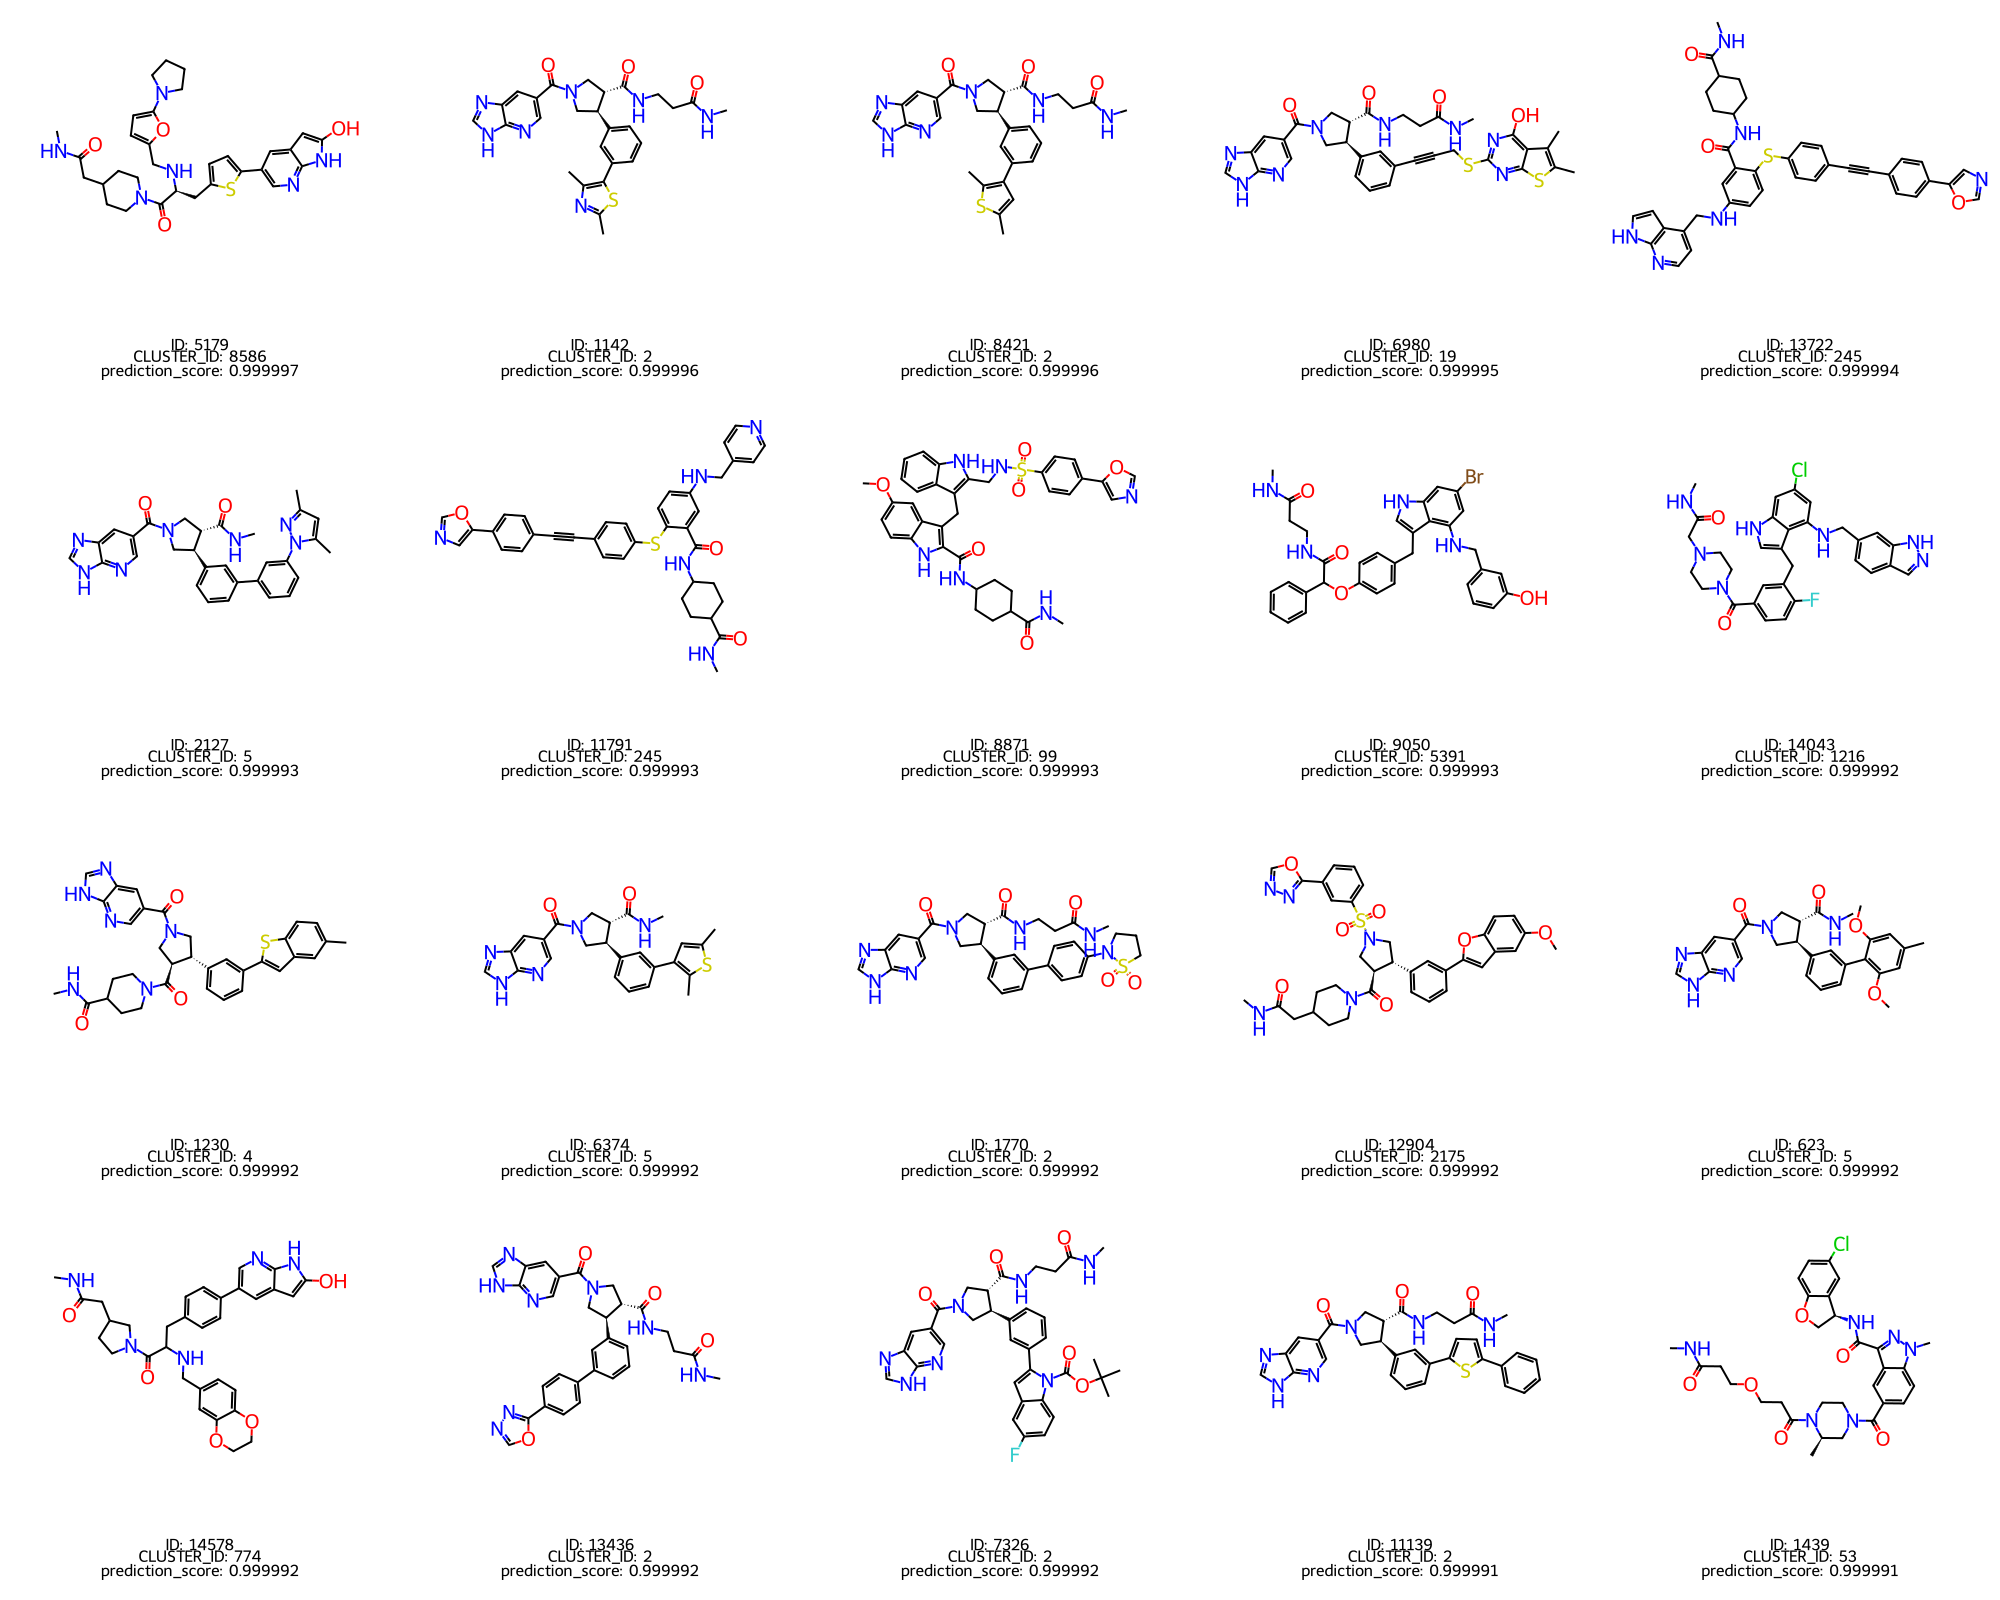

In [ ]:
#Visualize top hits #Leili - remove my name in final notebook
predictions_df_wclus = pd.concat([predictions_df,clusters_df],axis=1)
top20 = predictions_df_wclus.sort_values("prediction_score", ascending=False).head(20).reset_index(drop=True)
imglist=plotmolblocks_n(top20[SMILES_COLUMN],labels=top20[["ID","CLUSTER_ID","prediction_score"]])
imglist[0]